In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/gurgaon_properties_cleaned_v2.csv").drop_duplicates()

In [6]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,NaN,NaN,58141.0,0,0,0,0,0,0,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,...,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1995.0,1615.0,1476.0,0,1,0,0,1,1,174


In [7]:
df.shape

(3677, 23)

In [8]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

<Axes: xlabel='price', ylabel='Count'>

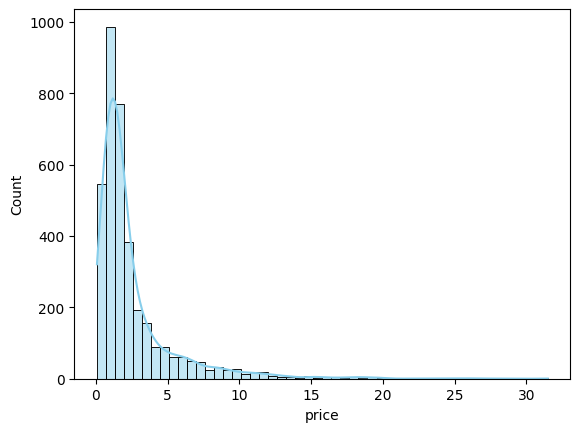

In [9]:
# outlier on basis of price
sns.histplot(x = df['price'] , kde = True , bins = 50 , color = 'skyblue')

<Axes: xlabel='price'>

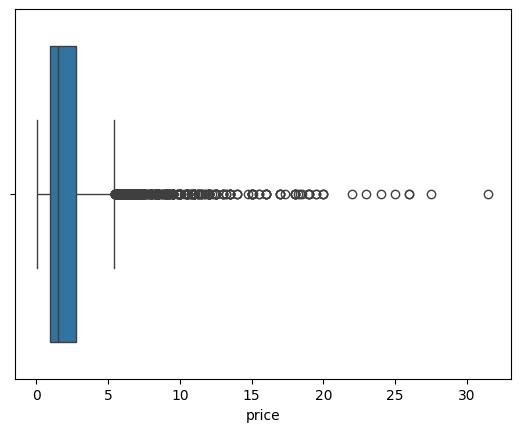

In [10]:
sns.boxplot(x = df['price'])

In [23]:
# calculate IQR for price col.
q1 = df['price'].quantile(.25)
q3 = df['price'].quantile(.75)
IQR = q3-q1

# define bounds for outliers
lower_bound = q1 - 1.5*IQR
upper_bound = q3 + 1.5*IQR

# identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers , outliers_price_stats

(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [16]:
df.sort_values('price' , ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
821,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,...,NaN,9000.0,NaN,1,1,1,1,0,2,74
2834,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,...,NaN,11286.0,NaN,1,1,0,1,1,1,42
2211,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,...,NaN,400.0,350.0,1,1,1,1,0,2,72
2488,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,...,NaN,4545.0,NaN,1,1,0,1,1,1,138
1686,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,...,NaN,1000.0,NaN,1,1,1,1,0,0,0
3046,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,...,NaN,400.0,NaN,1,1,0,1,0,1,122
2765,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,...,NaN,9000.0,NaN,1,1,1,1,0,1,145
2667,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,...,NaN,1000.0,NaN,0,1,0,0,0,0,54
2096,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,...,NaN,500.0,NaN,0,1,0,0,0,1,31
874,house,dlf city plots,sector 26,20.00,44265.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,...,NaN,4518.0,NaN,1,1,1,1,0,1,153


In [17]:
df.sort_values('price_per_sqft' , ascending=False).tail(50)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1010,flat,sidhartha ncr one phase,sector 95,0.43,3152.0,1364.0,Super Built up area 1364(126.72 sq.m.)Built Up...,2,2,2,...,1364.0,1300.0,1020.000000,0,0,0,0,0,0,120
889,flat,hcbs sports ville,sohna road,0.22,3142.0,700.0,Carpet area: 700 (65.03 sq.m.),1,1,1,...,NaN,NaN,700.000000,0,0,0,0,0,0,86
1362,flat,hsiidc sidco aravali,manesar,0.81,3129.0,2589.0,Super Built up area 2588(240.43 sq.m.)Built Up...,3,3,3+,...,2588.0,1900.0,1877.000000,0,1,0,0,0,0,74
672,flat,professional society,manesar,0.75,3067.0,2445.0,Carpet area: 2445 (227.15 sq.m.),3,4,3,...,NaN,NaN,2445.000000,0,1,0,0,0,0,21
1358,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,...,NaN,2660.0,2500.000000,0,1,0,0,0,1,61
3195,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,...,NaN,2850.0,2250.000000,1,1,0,1,1,1,123
208,flat,ramson kshitij sec-95 gurugram,sector 95,0.27,2700.0,1000.0,Super Built up area 1000(92.9 sq.m.)Carpet are...,2,2,0,...,1000.0,NaN,550.000000,0,0,0,0,0,0,0
1412,flat,hcbs sports ville,sohna road,0.20,2666.0,750.0,Super Built up area 750(69.68 sq.m.)Built Up a...,2,2,1,...,750.0,743.0,600.000000,0,0,0,0,0,0,15
2190,house,independent,sohna road,0.07,2525.0,277.0,Plot area 33(27.59 sq.m.),1,1,0,...,NaN,33.0,NaN,0,0,0,0,0,0,0
1980,house,bhim nagar society,sector 6,0.40,2500.0,1600.0,Built Up area: 1600 (148.64 sq.m.)Carpet area:...,4,2,2,...,NaN,1600.0,800.000000,0,0,0,0,0,0,0


In [18]:
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

### price per sqft

<Axes: xlabel='price_per_sqft', ylabel='Count'>

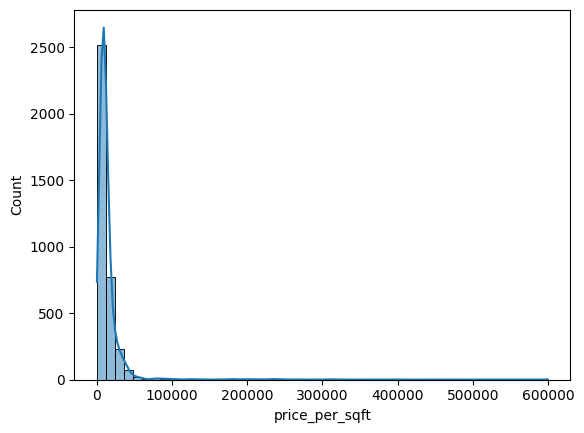

In [20]:
sns.histplot(x = df['price_per_sqft'] , kde = True , bins = 50)

<Axes: xlabel='price_per_sqft'>

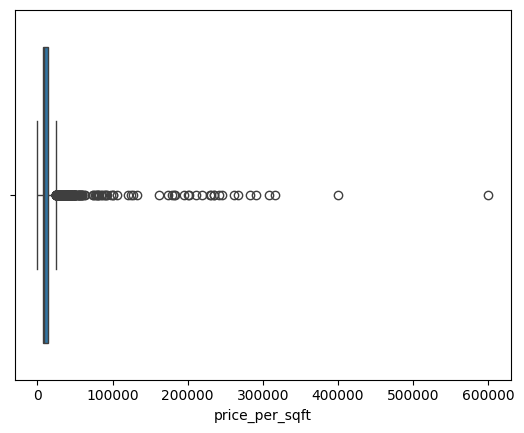

In [21]:
sns.boxplot(x = df['price_per_sqft'])

In [24]:
# calculate IQR for price col.
q1 = df['price_per_sqft'].quantile(.25)
q3 = df['price_per_sqft'].quantile(.75)
IQR = q3-q1

# define bounds for outliers
lower_bound = q1 - 1.5*IQR
upper_bound = q3 + 1.5*IQR

# identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

num_outliers_sqft = outliers.shape[0]
outliers_sqft_stats = outliers['price_per_sqft'].describe()

num_outliers_sqft , outliers_sqft_stats

(425,
 count       425.000000
 mean      36456.475294
 std       51784.501266
 min        1560.000000
 25%       19488.000000
 50%       26389.000000
 75%       35222.000000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [26]:
df.sort_values('price_per_sqft' , ascending=False).head(50)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3046,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,...,NaN,400.0,NaN,1,1,0,1,0,1,122
2850,house,dlf city plots phase 2,sector 25,10.00,400000.0,250.0,Plot area 250(23.23 sq.m.),12,12,3+,...,NaN,250.0,NaN,1,1,0,0,0,1,114
2461,house,independent,sector 12,6.00,315789.0,190.0,Plot area 190(17.65 sq.m.)Carpet area: 1600 sq...,9,6,2,...,NaN,NaN,1600.0,0,0,0,0,0,0,0
2047,house,ansal,sector 43,1.85,308333.0,60.0,Plot area 60(5.57 sq.m.),8,8,3+,...,NaN,60.0,NaN,0,0,0,0,0,0,53
975,house,uppal southend,sector 49,6.75,290948.0,232.0,Plot area 232(21.55 sq.m.),12,12,3+,...,NaN,232.0,NaN,1,1,0,1,1,1,49
342,house,unitech nirvana birch court,sector 50,7.10,283333.0,251.0,Plot area 240(22.3 sq.m.),3,3,3,...,NaN,240.0,NaN,0,1,0,0,0,0,49
3449,house,independent,sector 57,8.00,266666.0,300.0,Plot area 300(27.87 sq.m.),5,4,3,...,NaN,300.0,NaN,1,1,0,1,0,0,21
2161,house,dlf city plots phase 2,sector 25,10.50,261194.0,402.0,Plot area 402(37.35 sq.m.),4,4,2,...,NaN,402.0,NaN,0,1,0,1,0,1,91
3519,house,huda plot sector 38,sector 38,4.30,245398.0,175.0,Plot area 163(15.14 sq.m.)Built Up area: 145 s...,13,13,3+,...,NaN,145.0,NaN,0,0,0,0,0,2,7
2277,house,independent,sector 55,1.45,241666.0,60.0,Plot area 60(5.57 sq.m.),4,4,3+,...,NaN,60.0,NaN,0,0,1,0,0,0,70


In [27]:
# There is a data error , due to which price_per_sqft is so high , error is -> the rows in which area value are less than 1000 are not in sqft , instead they are in sq yard.

In [28]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x < 1000 else x)

/tmp/ipython-input-28-3567854082.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x < 1000 else x)


In [29]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000) / outliers_sqft['area'])

/tmp/ipython-input-29-971552380.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000) / outliers_sqft['area'])


In [31]:
outliers_sqft['price_per_sqft'].describe()

,price_per_sqft
count,354.000000
mean,29357.906780
std,12403.077309
min,2723.000000
25%,25562.000000
50%,29870.500000
75%,35549.500000
max,82540.000000


In [32]:
df.update(outliers_sqft)

<Axes: xlabel='price_per_sqft', ylabel='Count'>

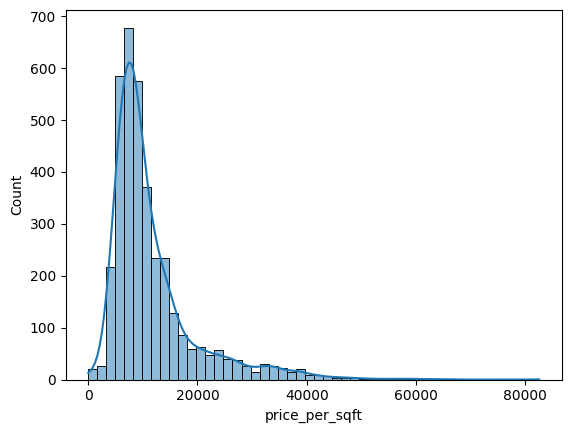

In [34]:
sns.histplot(x = df['price_per_sqft'] , kde = True , bins = 50)

<Axes: xlabel='price_per_sqft'>

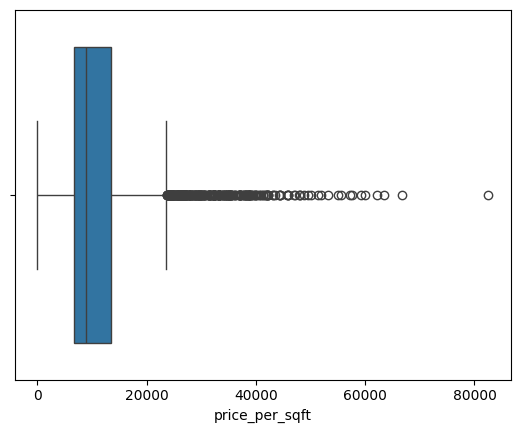

In [36]:
sns.boxplot(x = df['price_per_sqft'])

In [38]:
df[df['price_per_sqft'] > 50000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
386,house,cloudnine cottages,sohna road,5.50,55000.0,1000.0,Plot area 1000(92.9 sq.m.),3,3,0,...,NaN,1000.0,NaN,0,0,0,0,0,0,0
671,house,emaar mgf marbella,sector 66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,...,NaN,3240.0,NaN,1,1,0,1,0,2,75
1200,house,independent,sector 26,14.75,51864.0,2844.0,Plot area 316(264.22 sq.m.),16,20,3+,...,NaN,2844.0,NaN,1,1,1,1,0,1,153
1261,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,...,NaN,325.0,300.0,1,1,1,1,0,2,72
1349,flat,unitech vistas,sector 70,9.00,57508.0,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,0,...,NaN,1565.0,NaN,0,0,0,0,0,0,0
1425,house,project housing board colony,sector 31,8.00,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,...,NaN,140.0,NaN,0,0,0,0,0,0,0
1640,house,emaar the palm springs,sector 54,14.00,62222.0,2250.0,Plot area 250(209.03 sq.m.),4,5,3+,...,NaN,2250.0,NaN,1,1,0,0,0,1,160
1839,house,unitech escape,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,...,NaN,250.0,200.0,1,1,1,1,0,1,103
2211,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,...,NaN,400.0,350.0,1,1,1,1,0,2,72
2290,house,malibu towne,sector 47,8.50,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,...,NaN,1600.0,NaN,0,0,0,0,0,1,99


In [39]:
df = df[df['price_per_sqft']<50000]

<Axes: xlabel='price_per_sqft'>

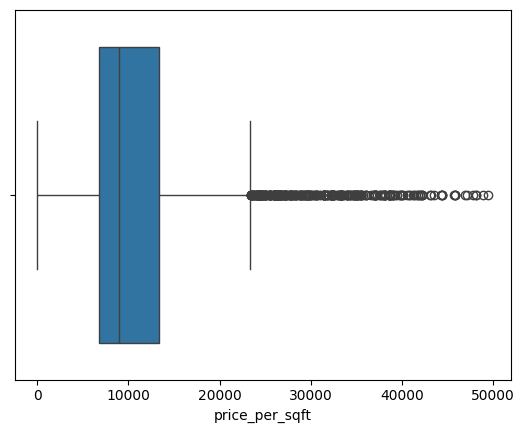

In [40]:
sns.boxplot(x = df['price_per_sqft'])

### area

<Axes: xlabel='area', ylabel='Count'>

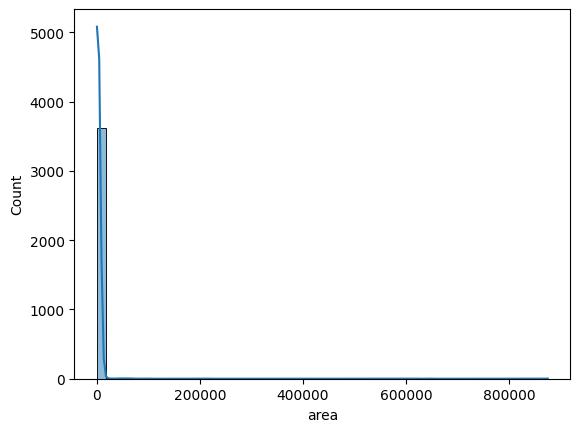

In [41]:
sns.histplot(x = df['area'] , kde =True , bins = 50)

<Axes: xlabel='area'>

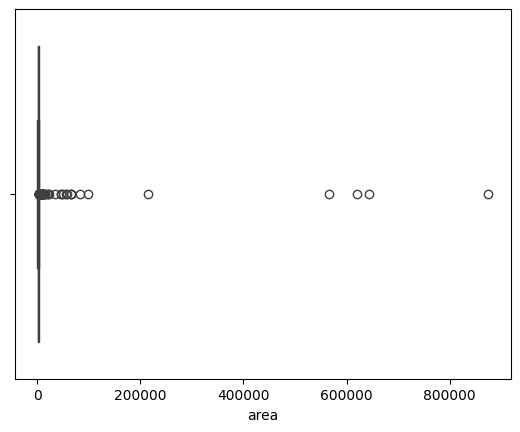

In [42]:
sns.boxplot(x = df['area'])

In [43]:
df['area'].describe()

,area
count,3646.000000
mean,2947.791552
std,23211.377087
min,145.000000
25%,1262.000000
50%,1750.000000
75%,2348.500000
max,875000.000000


In [44]:
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1638,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,...,NaN,NaN,514396.0,0,0,0,0,0,0,44
1648,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,...,NaN,737147.0,NaN,0,0,0,0,0,2,44
2111,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,...,NaN,NaN,569243.0,0,0,0,0,0,0,76
2651,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,...,NaN,NaN,607936.0,1,0,0,0,1,0,65
3021,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,...,NaN,2.0,NaN,1,1,0,1,1,1,0


In [45]:
df = df[df['area'] < 100000]


<Axes: xlabel='area', ylabel='Count'>

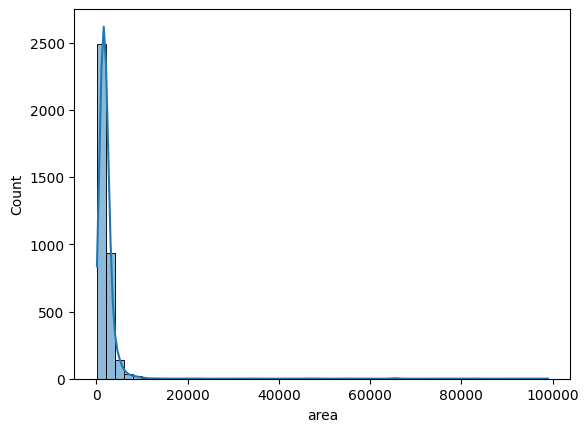

In [46]:
sns.histplot(x = df['area'] , kde = True , bins = 50)

<Axes: xlabel='area'>

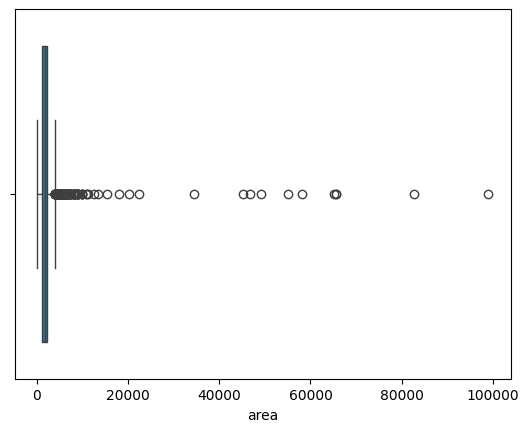

In [47]:
sns.boxplot(x = df['area'])

In [48]:
df[df['area']>10000].sort_values('area' , ascending=False)
# 818, 1796, 1123, 2, 2356, 115, 3649, 2503, 1471

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
818,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,...,NaN,NaN,11000.00,0,1,1,1,0,1,60
48,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,...,NaN,115.0,NaN,0,0,0,0,1,0,7
1123,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,...,NaN,NaN,64412.00,0,0,0,0,0,0,51
1796,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,...,NaN,NaN,64529.00,1,0,0,0,0,0,15
300,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,...,NaN,NaN,7250.00,0,0,0,0,0,0,0
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,NaN,NaN,58141.00,0,0,0,0,0,0,15
2356,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,...,NaN,NaN,54917.00,0,0,0,0,0,0,37
115,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,...,NaN,NaN,48811.00,1,0,0,0,0,0,37
2666,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,...,NaN,5800.0,5200.00,0,1,1,0,0,1,109
3649,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,...,NaN,NaN,45966.00,0,0,0,0,1,0,33


In [49]:
df.drop(index = [818, 1796, 1123, 2, 2356, 115, 3649, 2503, 1471],inplace=True)

In [50]:
df[df['area']>10000].sort_values('area' , ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
48,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,...,NaN,115.0,NaN,0,0,0,0,1,0,7
300,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,...,NaN,NaN,7250.00,0,0,0,0,0,0,0
2666,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,...,NaN,5800.0,5200.00,0,1,1,0,0,1,109
1358,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,...,NaN,2660.0,2500.00,0,1,0,0,0,1,61
3195,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,...,NaN,2850.0,2250.00,1,1,0,1,1,1,123
2131,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,...,NaN,NaN,18122.00,1,0,0,1,1,1,44
3088,house,unitech aspen greens,sector 50,6.95,4490.0,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,...,NaN,2160.0,1720.00,0,1,0,0,0,0,160
3444,flat,godrej icon,sector 88a,1.75,1384.0,12645.0,Carpet area: 1175.11,3,3,3+,...,NaN,NaN,1175.11,0,0,0,0,0,0,55
2834,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,...,NaN,11286.0,NaN,1,1,0,1,1,1,42
2342,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,...,NaN,NaN,11000.00,0,1,0,0,0,0,60


In [51]:
df.loc[48,'area'] = 115*9
df.loc[300,'area'] = 7250
df.loc[2666,'area'] = 5800
df.loc[1358,'area'] = 2660
df.loc[3195,'area'] = 2850
df.loc[2131,'area'] = 1812
df.loc[3088,'area'] = 2160
df.loc[3444,'area'] = 1175

<Axes: xlabel='area', ylabel='Count'>

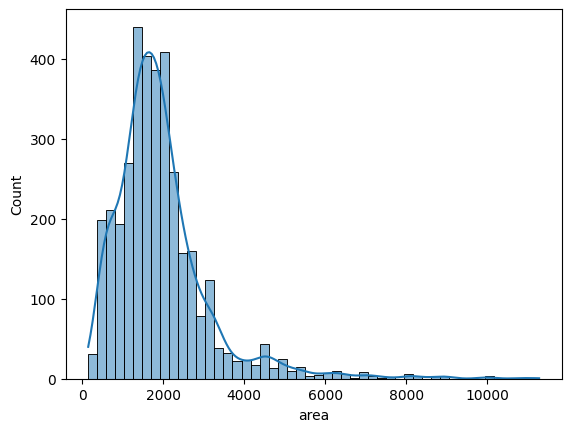

In [52]:
sns.histplot(x = df['area'] , kde = True , bins =50)

<Axes: xlabel='area'>

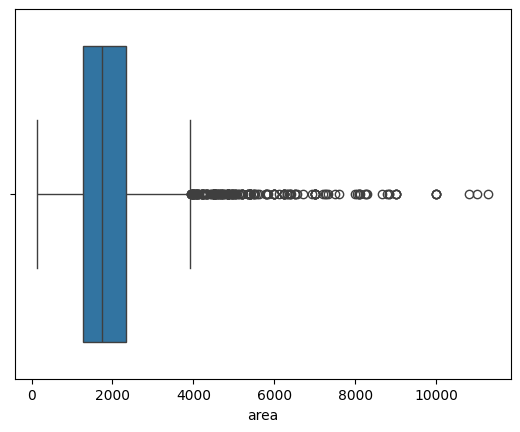

In [53]:
sns.boxplot(x = df['area'])

In [54]:
df['area'].describe()

,area
count,3632.000000
mean,1950.150606
std,1215.811628
min,145.000000
25%,1260.000000
50%,1746.500000
75%,2325.000000
max,11286.000000


### bedroom

<Axes: xlabel='bedRoom', ylabel='Count'>

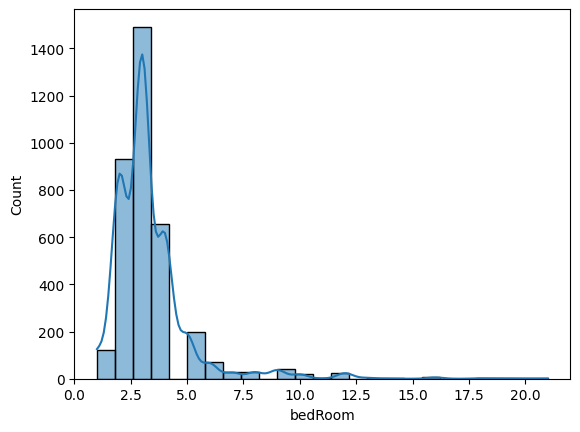

In [58]:
sns.histplot(x = df['bedRoom'] , kde = True , bins = 25)

<Axes: xlabel='bedRoom'>

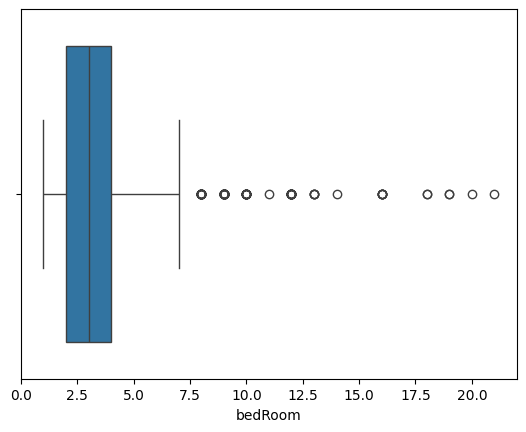

In [59]:
sns.boxplot(x = df['bedRoom'])

In [60]:
df['bedRoom'].describe()

,bedRoom
count,3632.000000
mean,3.330121
std,1.818173
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,21.000000


In [61]:
df[df['bedRoom'] > 10].sort_values('bedRoom' , ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3618,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,...,NaN,1161.0,NaN,0,1,0,0,0,2,49
2611,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,...,NaN,1152.0,NaN,0,1,0,0,0,2,22
78,house,independent,sector 17,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,...,NaN,7500.0,NaN,1,0,1,0,0,0,68
1493,house,independent,sector 17,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,...,NaN,1622.0,NaN,1,1,1,1,0,0,74
1381,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,...,NaN,1503.0,NaN,0,0,0,0,1,2,57
19,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,...,NaN,1440.0,NaN,0,1,0,0,0,2,70
3457,house,independent,sector 56,12.39,45889.0,2700.0,Plot area 300(250.84 sq.m.),16,18,3+,...,NaN,2700.0,NaN,0,1,0,1,0,1,49
3698,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16,18,2,...,NaN,2700.0,NaN,0,1,0,1,0,1,49
2137,house,independent,sector 40,12.00,38986.0,3078.0,Plot area 342(285.96 sq.m.),16,16,3+,...,NaN,3078.0,NaN,1,1,1,1,0,1,0
2096,house,luxury dlf city floors,sector 26,20.00,48888.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,...,NaN,500.0,NaN,0,1,0,0,0,1,31


In [62]:
df = df[df['bedRoom'] <= 10]

In [63]:
df.shape

(3588, 23)

<Axes: xlabel='bedRoom', ylabel='Count'>

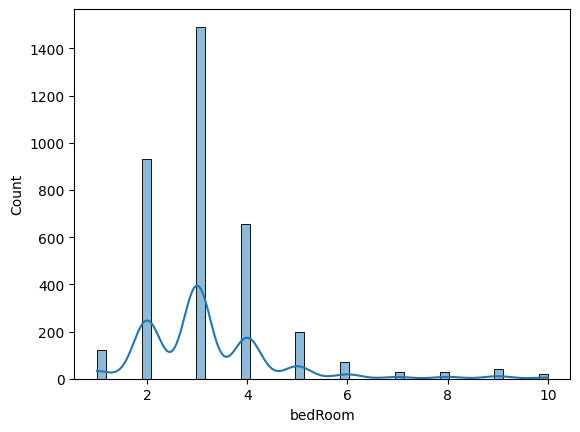

In [64]:
sns.histplot(df['bedRoom'] , bins = 50 , kde = True)

<Axes: xlabel='bedRoom'>

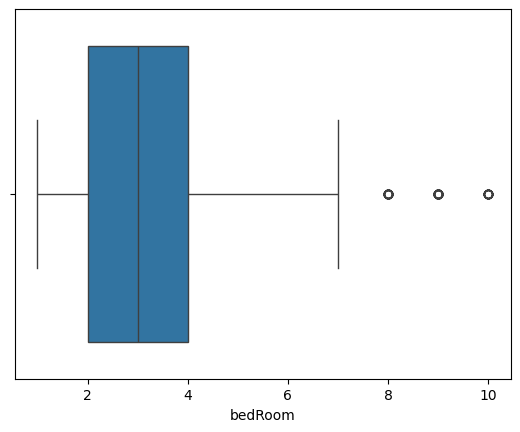

In [65]:
sns.boxplot(x = df['bedRoom'])

In [66]:
df['bedRoom'].describe()

,bedRoom
count,3588.000000
mean,3.203735
std,1.393968
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,10.000000


### bathroom

<Axes: xlabel='bathroom', ylabel='Count'>

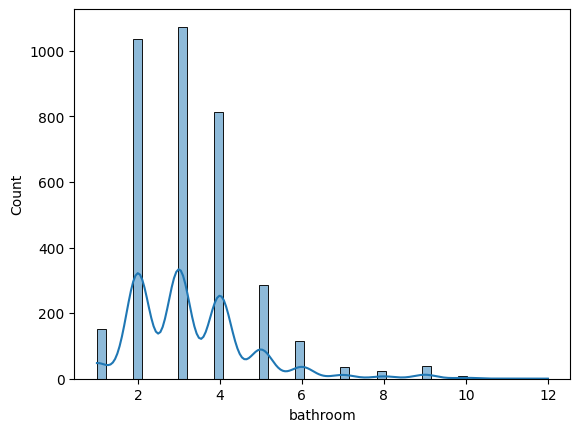

In [67]:
sns.histplot(df['bathroom'] , bins = 50 , kde = True)

<Axes: xlabel='bathroom'>

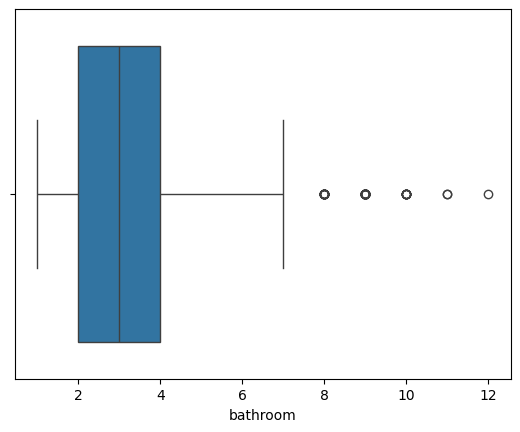

In [68]:
sns.boxplot(x = df['bathroom'])

In [69]:
df[df['bathroom'] > 10 ].sort_values('bathroom' , ascending = False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3267,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,...,NaN,6390.0,NaN,0,1,0,0,0,1,146
2771,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,...,NaN,7000.0,NaN,0,0,0,1,0,2,38
2816,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,...,NaN,5000.0,NaN,1,1,0,1,1,1,39


In [70]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,...,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1995.0,1615.0,1476.0,0,1,0,0,1,1,174
5,flat,suncity avenue,sector 102,0.48,9022.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet are...,2,2,1,...,632.0,NaN,532.0,0,0,1,0,0,0,159


### super built up area

<Axes: xlabel='super_built_up_area', ylabel='Count'>

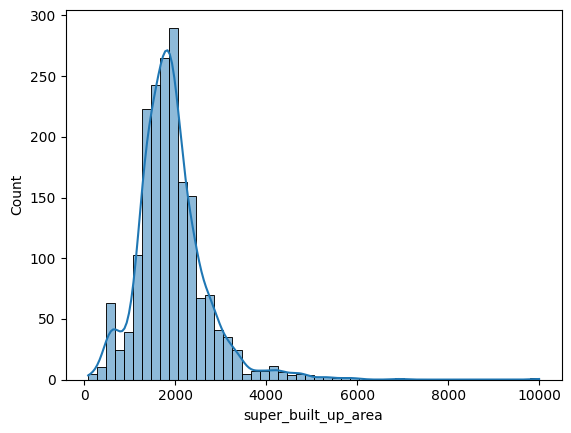

In [71]:
sns.histplot(df['super_built_up_area'] , bins =50 , kde = True)

<Axes: xlabel='super_built_up_area'>

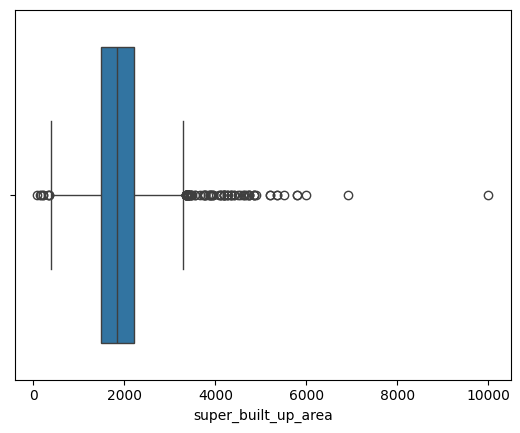

In [72]:
sns.boxplot(x = df['super_built_up_area'])

In [73]:
df['super_built_up_area'].describe()

,super_built_up_area
count,1875.000000
mean,1925.237627
std,764.172177
min,89.000000
25%,1479.500000
50%,1828.000000
75%,2215.000000
max,10000.000000


In [74]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1323,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,...,6926.0,NaN,NaN,0,1,0,0,0,1,140
3265,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,...,10000.0,NaN,NaN,0,1,0,1,1,0,49


### built up area

<Axes: xlabel='built_up_area', ylabel='Count'>

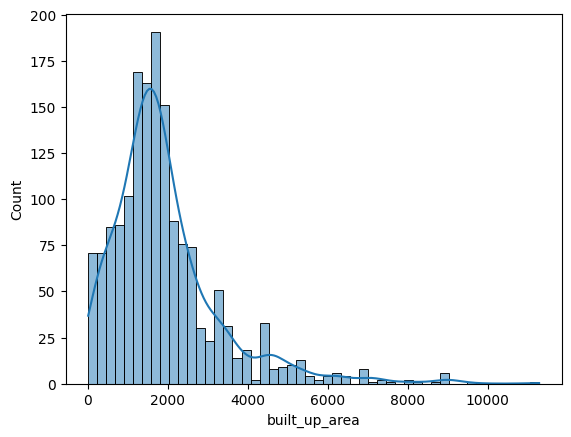

In [75]:
sns.histplot(df['built_up_area'] , bins =50 , kde = True)

<Axes: xlabel='built_up_area'>

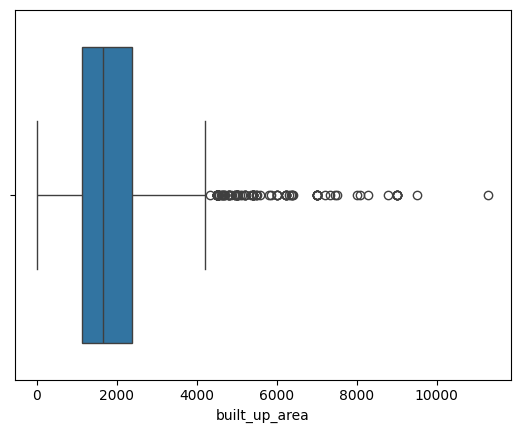

In [76]:
sns.boxplot(x = df['built_up_area'])

In [77]:
df['built_up_area'].describe()

,built_up_area
count,1613.000000
mean,1938.088673
std,1398.149189
min,14.000000
25%,1120.000000
50%,1650.000000
75%,2385.000000
max,11286.000000


In [78]:
df[df['built_up_area']>10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2834,house,independent,sector 43,27.5,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,...,NaN,11286.0,NaN,1,1,0,1,1,1,42


### carpet area

<Axes: xlabel='carpet_area', ylabel='Count'>

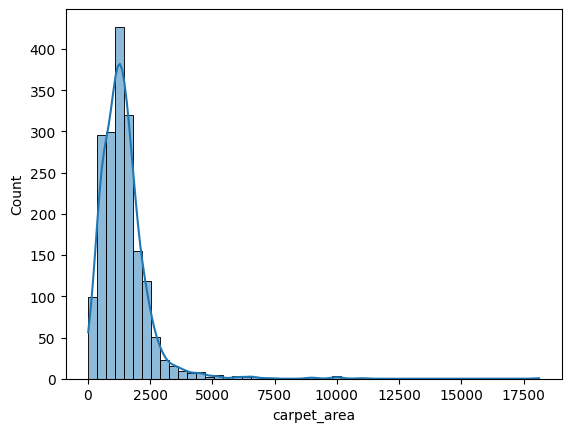

In [79]:
sns.histplot(df['carpet_area'] , bins =50 , kde = True)

<Axes: xlabel='carpet_area'>

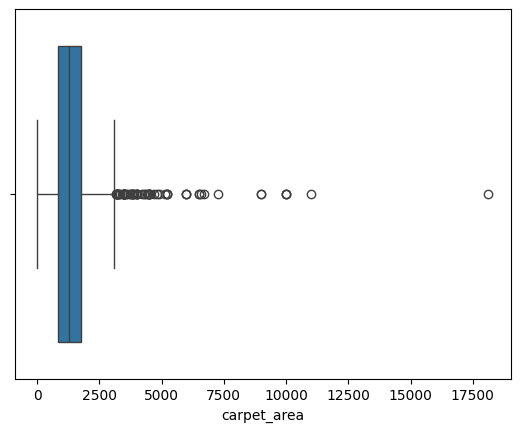

In [80]:
sns.boxplot(x = df['carpet_area'])

In [81]:
df['carpet_area'].describe()

,carpet_area
count,1850.000000
mean,1433.470204
std,1041.839596
min,15.000000
25%,845.000000
50%,1300.000000
75%,1764.797500
max,18122.000000


In [82]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2131,flat,godrej air,sector 85,2.5,1379.0,1812.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,...,NaN,NaN,18122.0,1,0,0,1,1,1,44
2342,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,...,NaN,NaN,11000.0,0,1,0,0,0,0,60


In [87]:
df.loc[2131 , 'carpet_area'] = 1812

In [88]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,...,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1995.0,1615.0,1476.0,0,1,0,0,1,1,174
5,flat,suncity avenue,sector 102,0.48,9022.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet are...,2,2,1,...,632.0,NaN,532.0,0,0,1,0,0,0,159


### luxury_score

<Axes: xlabel='luxury_score', ylabel='Count'>

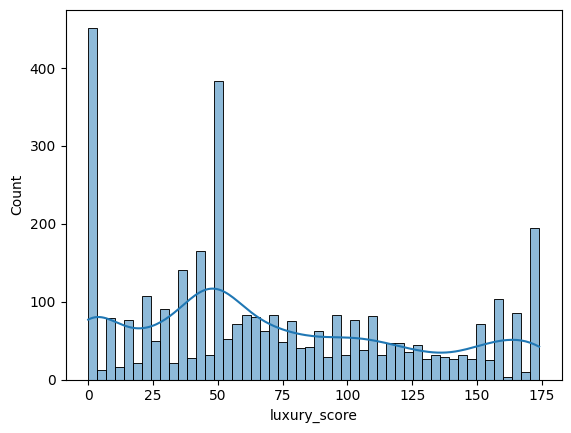

In [89]:
sns.histplot(df['luxury_score'] , kde = True , bins = 50)

<Axes: xlabel='luxury_score'>

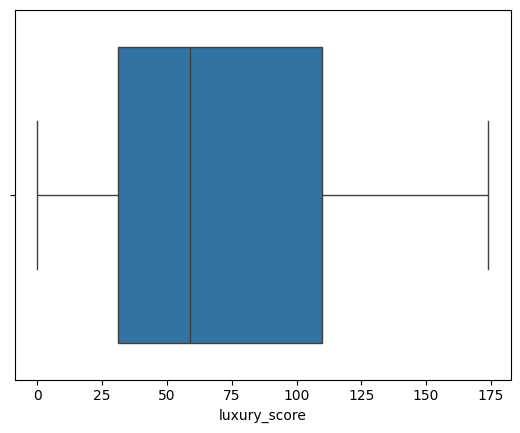

In [90]:
sns.boxplot(x = df['luxury_score'])

In [91]:
df['luxury_score'].describe()

,luxury_score
count,3588.000000
mean,71.825808
std,53.249381
min,0.000000
25%,31.000000
50%,59.000000
75%,110.000000
max,174.000000


In [92]:
df.shape

(3588, 23)

In [93]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [94]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8597.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,...,NaN,1000.0,585.0,0,0,0,0,0,0,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1995.0,1615.0,1476.0,0,1,0,0,1,1,174
5,flat,suncity avenue,sector 102,0.48,9023.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet are...,2,2,1,...,632.0,NaN,532.0,0,0,1,0,0,0,159


<Axes: xlabel='price_per_sqft', ylabel='Count'>

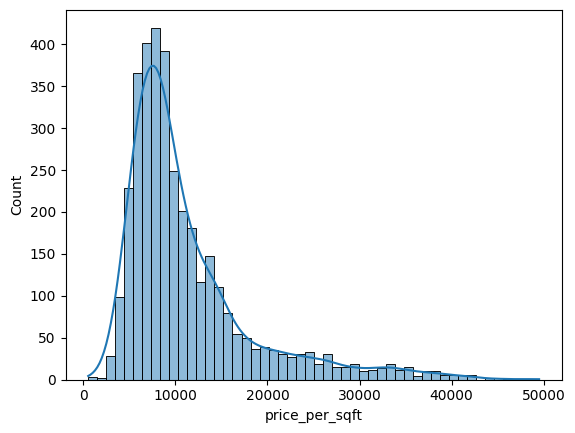

In [95]:
sns.histplot(df['price_per_sqft'] , bins = 50 , kde = True)

<Axes: xlabel='price_per_sqft'>

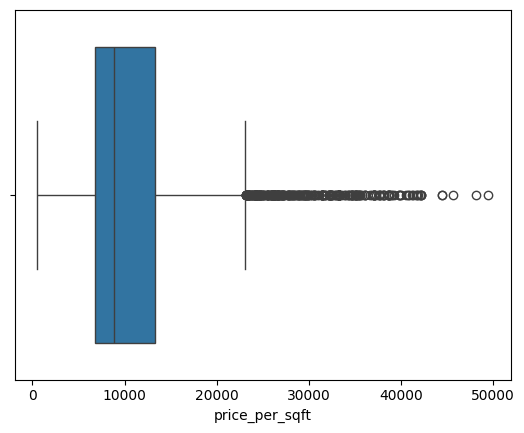

In [96]:
sns.boxplot(x = df['price_per_sqft'])

In [97]:
df['price_per_sqft'].describe()

,price_per_sqft
count,3588.000000
mean,11285.669175
std,7075.103090
min,544.000000
25%,6756.500000
50%,8912.500000
75%,13296.250000
max,49500.000000


In [98]:
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
711,house,independent,sector 26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,...,NaN,4500.0,NaN,0,1,0,1,0,2,97
901,house,independent,sector 28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4,5,3+,...,NaN,2844.0,NaN,0,1,1,1,0,1,60
1090,house,independent,sector 105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,...,NaN,2000.0,1800.0,0,0,0,0,0,0,0
1509,house,independent,sector 55,5.0,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,...,NaN,115.0,100.0,0,0,0,0,1,1,44
1526,house,dlf city plots,sector 26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6,6,3,...,NaN,4518.0,NaN,1,1,0,0,0,1,121
2040,house,independent,sector 43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,3+,...,NaN,300.0,250.0,0,1,0,1,0,1,88
2130,house,independent,sector 26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,...,NaN,4500.0,NaN,1,1,1,1,0,1,103
3054,house,sushant lok 1 builder floors,sector 43,13.0,48148.0,2700.0,Plot area 300(250.84 sq.m.),3,3,3+,...,NaN,2700.0,NaN,0,0,0,1,0,1,7
3108,house,independent,sector 25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6,8,3+,...,NaN,2844.0,NaN,1,1,1,1,0,2,0


In [101]:
x = df[df['price_per_sqft'] < 20000]
(x['area']/x['bedRoom']).quantile(0.05)

np.float64(250.5)

In [102]:
df[(df['area']/df['bedRoom']) < 250]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
9,house,independent,sector 105,1.20,10118.0,1186.0,Plot area 1185.51(110.14 sq.m.),6,2,1,...,NaN,1185.51,NaN,0,0,0,0,0,0,9
15,house,independent,sector 12,1.20,14184.0,846.0,Plot area 846(78.6 sq.m.)Built Up area: 846 sq...,4,4,2,...,NaN,846.00,NaN,0,0,0,1,0,1,7
37,house,independent,sector 104,0.45,12162.0,370.0,Plot area 370(34.37 sq.m.)Carpet area: 1500 sq...,4,4,2,...,NaN,NaN,1500.0,0,0,0,0,0,1,7
48,house,ganpati heights apartment,sector 13,1.25,12077.0,1035.0,Plot area 115(7692.86 sq.m.),10,6,2,...,NaN,115.00,NaN,0,0,0,0,1,0,7
74,house,independent,sector 25,7.60,38756.0,1961.0,Plot area 215(179.77 sq.m.),9,9,3,...,NaN,1935.00,NaN,1,0,1,1,0,1,84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3713,house,independent,sector 41,4.25,26235.0,1620.0,Plot area 180(150.5 sq.m.),10,9,3+,...,NaN,1620.00,NaN,1,1,0,0,0,1,36
3738,house,independent,sector 7,1.16,11694.0,992.0,Plot area 992(92.16 sq.m.)Carpet area: 992 sq....,5,4,2,...,NaN,NaN,992.0,0,0,0,0,1,0,39
3751,house,independent,sector 21,0.45,8411.0,535.0,Carpet area: 535 (49.7 sq.m.),3,2,1,...,NaN,NaN,535.0,0,0,0,0,0,0,0
3774,house,independent,sector 28,0.45,10000.0,450.0,Built Up area: 50 (4.65 sq.m.),5,3,0,...,NaN,50.00,NaN,0,0,0,0,0,0,0


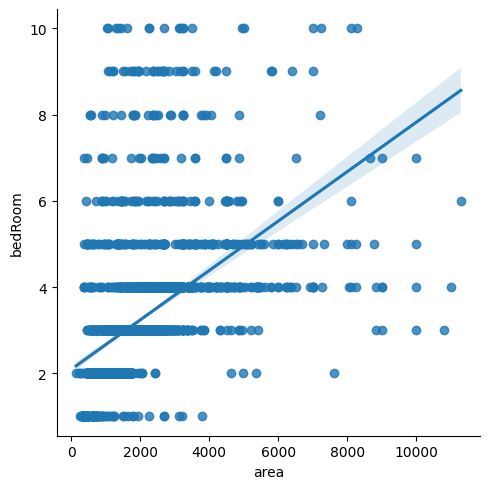

In [103]:
sns.lmplot(data=df , x = 'area' , y = 'bedRoom')

In [104]:
df['area_room_ratio'] = df['area']/df['bedRoom']

In [106]:
df[df['area_room_ratio'] < 250]['bedRoom'].value_counts()

,count
bedRoom,
2,47
3,33
5,28
6,17
4,17
9,15
8,12
10,8
7,8


In [107]:
df = df[df['area_room_ratio'] > 100]

In [108]:
outliers_df = df[(df['area_room_ratio'] < 250) & (df['bedRoom']>3)]

In [109]:
outliers_df['bedRoom'] = round(outliers_df['bedRoom']/outliers_df['floorNum'])

/tmp/ipython-input-109-3450078040.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_df['bedRoom'] = round(outliers_df['bedRoom']/outliers_df['floorNum'])


In [110]:
df.update(outliers_df)

In [111]:
df['area_room_ratio'] = df['area']/df['bedRoom']

/tmp/ipython-input-111-465686754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['area_room_ratio'] = df['area']/df['bedRoom']


In [118]:
x = df[(df['area_room_ratio'] < 250) & (df['bedRoom']>4)]
x.index

Index([93, 387, 753, 1106, 1206, 1747, 1936, 1939, 2806, 3148, 3246, 3329,
       3633],
      dtype='int64')

In [119]:
df.drop(index = [93, 387, 753, 1106, 1206, 1747, 1936, 1939, 2806, 3148, 3246, 3329,
       3633] , inplace = True)

/tmp/ipython-input-119-3118086930.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(index = [93, 387, 753, 1106, 1206, 1747, 1936, 1939, 2806, 3148, 3246, 3329,


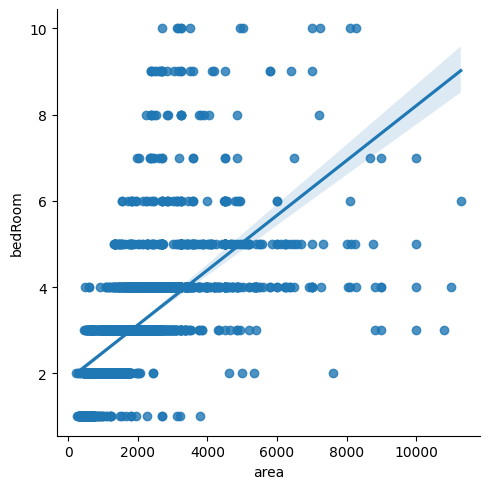

In [120]:
sns.lmplot(data=df , x = 'area' , y = 'bedRoom')

In [121]:
df.shape

(3555, 24)

In [122]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,signature global park 4,sector 36,0.82,7586.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,NaN,650.0,0,0,0,0,0,0,8,360.333333
1,flat,smart world gems,sector 89,0.95,8597.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,1103.0,1,1,0,0,0,0,38,552.500000
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,...,1000.0,585.0,0,0,0,0,0,0,49,292.500000
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1615.0,1476.0,0,1,0,0,1,1,174,665.000000
5,flat,suncity avenue,sector 102,0.48,9023.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet are...,2,2,1,...,NaN,532.0,0,0,1,0,0,0,159,266.000000


In [123]:
df. to_csv('durgaon_properties_outlier_treated.csv',index=False)